# Analysis of GitHub Language Trends (Long-Term Evolution)

### Course:
Big Data Engineering, FH Technikum Wien, Summer Semester 2025

### Team Members:
- Manpreet Misson  
- Timothy Gregorian  
- Omar Sidi Mammar

### Notebook Description  
This notebook analyzes the long-term evolution of programming language popularity on GitHub from **2015 to 2024**, based on cleaned API data.

Using **Apache Spark**, the data is read directly from an **S3-compatible object store**, exploded into individual language entries, and aggregated to extract key metrics per year—both in terms of **code volume (bytes)** and **repository count**.

The notebook identifies:
- The **most dominant language per year** by total bytes of code.
- The **top 5 languages per year** by number of repositories.
- A **trend score** per language based on average yearly repository growth, scaled between 0 and 10.

The results are visualized using bar and area plots, and a trend summary is exported as a CSV file.

### Goals of this Notebook
- Load structured GitHub API data from S3.
- Normalize and aggregate usage data per language and year.
- Identify dominant languages and growth trends from 2015–2024.
- Visualize the results and export a trend score dataset.


### Import Dependencies  
Load essential libraries for Spark processing, data visualization, JSON handling, and logging.


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, explode
from pyspark.sql.types import StructType, StringType, IntegerType, MapType
from pyspark.sql.functions import to_timestamp, year, explode
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import logging
import json
import os
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger("KafkaProducer")

### Initialize Spark Session for S3 Integration  
Create a Spark session configured to connect to a MinIO (S3-compatible) object storage. The session is also set up with custom access credentials and endpoint settings for data access.


In [2]:
spark = SparkSession.builder \
    .appName("GitHubLanguageTrends") \
    .master("local[*]") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://172.29.16.105:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "bdenggroup4") \
    .config("spark.hadoop.fs.s3a.secret.key", "bdenggroup4") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/23 15:30:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/06/23 15:30:34 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/06/23 15:30:34 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/06/23 15:30:34 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/06/23 15:30:34 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
25/06/23 15:30:34 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
25/06/23 15:30:34 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.


### Load and Prepare GitHub API Data from S3  
Define the schema for the cleaned GitHub API JSON file, read it from S3, and extract the creation year of each repository for time-based analysis.


In [3]:
schema = StructType() \
    .add("full_name", StringType()) \
    .add("stargazers_count", IntegerType()) \
    .add("created_at", StringType()) \
    .add("languages", MapType(StringType(), IntegerType()))

json_path = "s3a://bdenggroup4/All_API_Requests_Cleaned.json"

df = spark.read \
    .option("multiline", True) \
    .schema(schema) \
    .json(json_path)

df = df.withColumn("year", year(col("created_at")))
df.printSchema()
df.show(5, truncate=False)


root
 |-- full_name: string (nullable = true)
 |-- stargazers_count: integer (nullable = true)
 |-- created_at: string (nullable = true)
 |-- languages: map (nullable = true)
 |    |-- key: string
 |    |-- value: integer (valueContainsNull = true)
 |-- year: integer (nullable = true)



+---------------------+----------------+--------------------+-----------------------------------------------------------------------------------------------------------------------------------+----+
|full_name            |stargazers_count|created_at          |languages                                                                                                                          |year|
+---------------------+----------------+--------------------+-----------------------------------------------------------------------------------------------------------------------------------+----+
|mojombo/grit         |1988            |2007-10-29T14:37:16Z|{Ruby -> 219981}                                                                                                                   |2007|
|rails/rails          |56996           |2008-04-11T02:19:47Z|{Ruby -> 17345323, JavaScript -> 230742}                                                                                           |2008|
|git/

### Parse Timestamps and Explode Language Map
Convert the created_at string to a proper timestamp, extract the year from it, and transform the languages map into individual rows using explode, resulting in one row per language per repository-year.

In [4]:
df = df.withColumn("created_at", to_timestamp("created_at"))
df = df.withColumn("year", year("created_at"))
df_exploded = df.select("year", explode("languages").alias("language", "bytes"))


### Create Temporary SQL View for Language Usage
Register the exploded DataFrame as a temporary view named language_yearly_bytes, allowing SQL queries on yearly language usage. Then display the first 10 rows to preview the structure.


In [5]:
df_exploded.createOrReplaceTempView("language_yearly_bytes")
df_exploded.show(10)

+----+----------+--------+
|year|  language|   bytes|
+----+----------+--------+
|2007|      Ruby|  219981|
|2008|      Ruby|17345323|
|2008|JavaScript|  230742|
|2008|         C|11433414|
|2008|      Perl| 1111447|
|2008|    Python|  183463|
|2008|JavaScript|   49713|
|2008|       C++|   26403|
|2008|        Go|   15064|
|2008|      Rust|    6798|
+----+----------+--------+
only showing top 10 rows



### Identify Top Language per Year by Total Bytes
Use a SQL query to select the most dominant programming language for each year based on total bytes of code. This is done by ranking languages within each year using ROW_NUMBER() and filtering for the top-ranked entry (rank = 1).

In [6]:
top_lang_per_year = spark.sql("""
    SELECT year, language, total_bytes
    FROM (
        SELECT
            year,
            language,
            bytes AS total_bytes,
            ROW_NUMBER() OVER (PARTITION BY year ORDER BY bytes DESC) as rank
        FROM language_yearly_bytes
    )
    WHERE rank = 1
    ORDER BY year
""")
top_lang_per_year.show()


+----+----------+-----------+
|year|  language|total_bytes|
+----+----------+-----------+
|2007|      Ruby|     219981|
|2008|         C| 1349814934|
|2009|      Java|  465917839|
|2010|      Java| 1022743016|
|2011|         C| 1355010961|
|2012|         C| 1330355945|
|2013|         C|  607084392|
|2014|       C++|  275609430|
|2015|        C#|  215594435|
|2016|       C++|  486559070|
|2017|      Java|  887648653|
|2018|       C++|  810073105|
|2019|         C| 1219331479|
|2020|JavaScript|  638857104|
|2021|         C|  889248732|
|2022|         C|  103111851|
|2023|    Python|   88319299|
|2024|JavaScript|  302365184|
+----+----------+-----------+



### Count Repository Occurrences per Language and Year
Create a temporary view language_usage containing only the year and language columns. Then, run a SQL query to count how many repositories used each language per year, storing the result as language_yearly_counts.


In [7]:
df_exploded.select("year", "language").createOrReplaceTempView("language_usage")

df_counts = spark.sql("""
    SELECT
        year,
        language,
        COUNT(*) AS repo_count
    FROM language_usage
    GROUP BY year, language
""")
df_counts.createOrReplaceTempView("language_yearly_counts")


### Visualize Yearly Code Volume by Language (Stacked Bar Chart)

The top language data is converted to a Pandas DataFrame and reshaped into a pivot table to display the total bytes of code per language and year. A stacked bar chart visualizes the yearly distribution of code volume across languages.

Each bar represents the total code volume for a given year, with stacked segments showing the relative contribution of each language. The exact total per year is annotated above each bar for clarity.


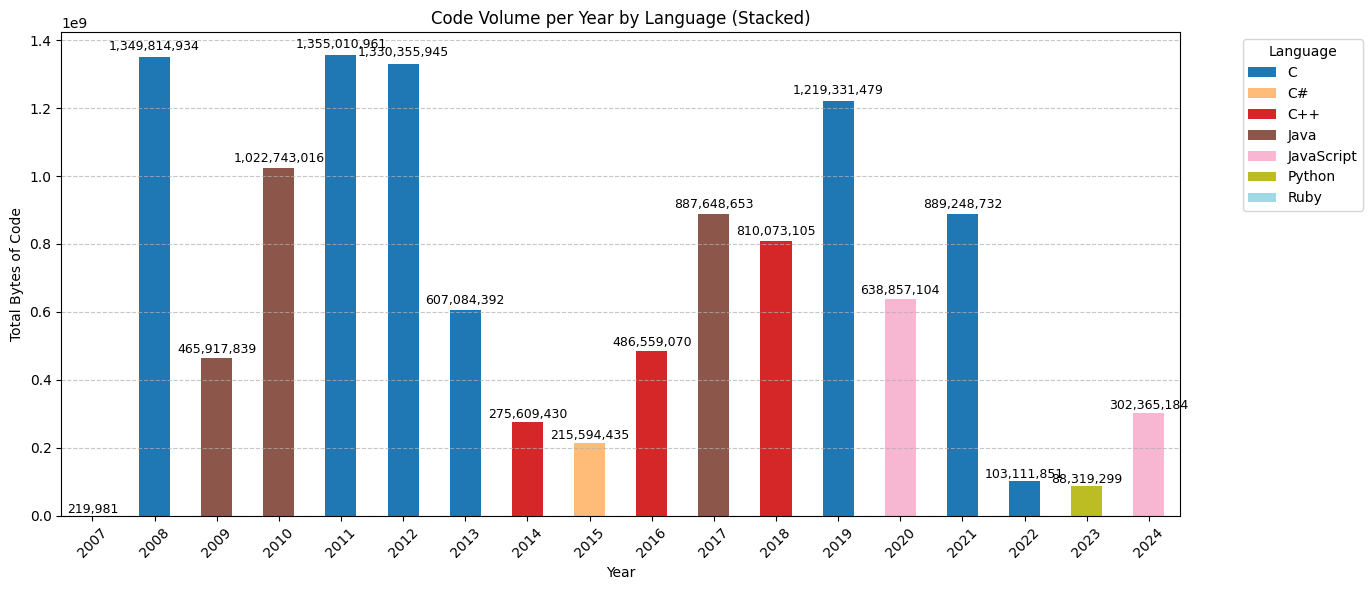

In [8]:
top_bytes_pd = top_lang_per_year.toPandas().sort_values("year")
pivot = top_bytes_pd.pivot(index="year", columns="language", values="total_bytes").fillna(0)

ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20"
)

plt.title("Code Volume per Year by Language (Stacked)")
plt.xlabel("Year")
plt.ylabel("Total Bytes of Code")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, axis="y", linestyle="--", alpha=0.7)

for i, year in enumerate(pivot.index):
    total = int(pivot.loc[year].sum())
    ax.text(i, total + total * 0.01, f"{total:,}",  # mit Tausender-Trennzeichen
            ha='center', va='bottom', fontsize=9, rotation=0)

plt.legend(title="Language", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### Identify Top 5 Languages per Year by Repository Count

This SQL query ranks programming languages each year by their number of repositories using `ROW_NUMBER()`. It selects the **top 5 most used languages per year**, providing a year-over-year view of language popularity based on repository activity.

The result helps to highlight shifts in developer preferences and the emergence of new dominant languages across time.


In [9]:
top_count_lang_per_year = spark.sql("""
    SELECT year, language, repo_count
    FROM (
        SELECT
            year,
            language,
            repo_count,
            ROW_NUMBER() OVER (PARTITION BY year ORDER BY repo_count DESC) as rank
        FROM language_yearly_counts
    )
    WHERE rank <= 5
    ORDER BY year
""")

top_count_lang_per_year.show()

+----+----------+----------+
|year|  language|repo_count|
+----+----------+----------+
|2007|      Ruby|         1|
|2008|      Ruby|       326|
|2008|JavaScript|       138|
|2008|         C|        93|
|2008|    Python|        76|
|2008|       C++|        47|
|2009|      Ruby|       174|
|2009|JavaScript|       164|
|2009|    Python|       130|
|2009|         C|       106|
|2009|       C++|        71|
|2010|JavaScript|       247|
|2010|    Python|       156|
|2010|         C|       108|
|2010|      Ruby|       101|
|2010|       C++|        75|
|2011|JavaScript|       249|
|2011|    Python|       137|
|2011|         C|       113|
|2011|      Java|        73|
+----+----------+----------+
only showing top 20 rows



### Visualize Top Languages per Year by Repository Count (Stacked Bar Chart)

Convert the SQL result to a Pandas DataFrame and reshape it into a pivot table to show repository counts by year and language. A stacked bar chart visualizes the top 5 programming languages per year based on repository activity.

Each bar represents the total number of repositories for that year, with segments showing language contributions. Annotations indicate the yearly total and the most used language, emphasizing trends and shifts in languag


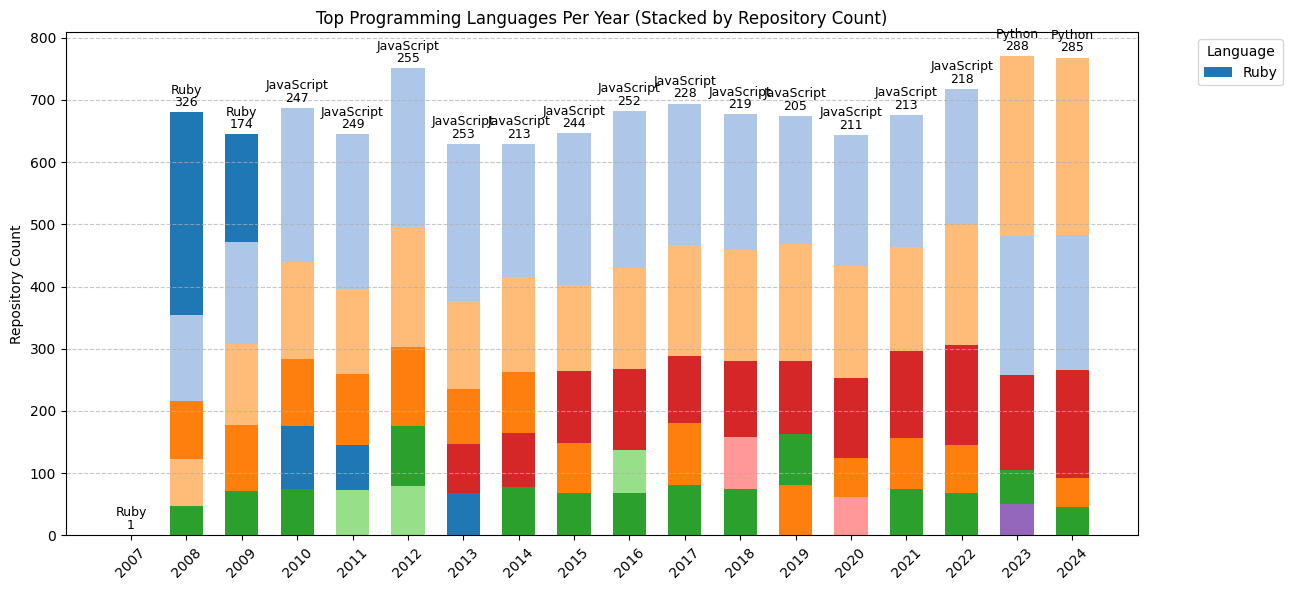

In [19]:
top_langs_pd = top_count_lang_per_year.toPandas()
years = sorted(top_langs_pd["year"].unique())
languages = top_langs_pd["language"].unique()

fig, ax = plt.subplots(figsize=(13, 6))
bar_width = 0.6

colors = plt.get_cmap("tab20").colors
color_map = {lang: colors[i % len(colors)] for i, lang in enumerate(languages)}

for i, year in enumerate(years):
    df_year = top_langs_pd[top_langs_pd["year"] == year].sort_values("repo_count")
    bottom = 0
    for _, row in df_year.iterrows():
        lang = row["language"]
        count = row["repo_count"]
        ax.bar(i, count, bottom=bottom, width=bar_width, label=lang if i == 0 else "", color=color_map[lang])
        bottom += count

    top_row = df_year.iloc[-1]
    ax.text(i, bottom + 5, f"{top_row['repo_count']}", ha="center", va="bottom", fontsize=9)
    ax.text(i, bottom + 25, f"{top_row['language']}", ha="center", va="bottom", fontsize=9, color="black")

ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)
ax.set_title("Top Programming Languages Per Year (Stacked by Repository Count)")
ax.set_ylabel("Repository Count")
ax.legend(title="Language", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


### Calculate Trend Score for Programming Languages (2015–2024)
Filter the yearly repository data to include only the years 2015–2024. Then, compute the average annual growth in repository count per language to derive a data-driven trend_score. This score reflects the growth momentum of each language over the observed decade. The result is normalized to a 0–10 scale for interpretability and later use in combined future analyses.


In [ ]:
output_dir = "./RestAPIData"
os.makedirs(output_dir, exist_ok=True)

df_counts = spark.sql("""
    SELECT * FROM language_yearly_counts
    WHERE year BETWEEN 2015 AND 2024
""").toPandas()

df_counts = df_counts.dropna()
df_counts["year"] = df_counts["year"].astype(int)
df_counts["repo_count"] = df_counts["repo_count"].astype(int)
df_counts = df_counts.sort_values(["language", "year"])

trend_df = (
    df_counts.groupby("language")["repo_count"]
    .apply(lambda x: x.diff().mean())  # yearly increase
    .reset_index(name="trend_raw")
)

scaler = MinMaxScaler()
trend_df["trend_score"] = scaler.fit_transform(trend_df[["trend_raw"]]) * 10
trend_df["trend_score"] = trend_df["trend_score"].round(1)

print("Trend Scores (based on repository growth from 2015 to 2024):")
print(trend_df.sort_values("trend_score", ascending=False).to_string(index=False))

output_path = os.path.join(output_dir, "trend_score_repo_growth_2015_2024.csv")
trend_df.to_csv(output_path, index=False)
print(f"\n File saved to: {output_path}")


In [ ]:
spark.stop()
logger.info("Spark session stopped.")